https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_1995-2023.csv

I need to do an appendix for my references?

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

### Dataset Background and Source

The Earthquake dataset was sourced from the United States Geological Survey (USGS) earthquake everywhere API and uploaded to Kaggle by Chirag Chauhan. It comprises data on 782 significant global earthquakes from 2001–2022 which supports research in earthquake analysis, tsunami risk prediction and seismic hazard assessment (Chauhan, 2024)


### My goal

My goal is to predict the occurrence of tsunamis following earthquakes based on the characteristics of the seismic events.

#### Stakeholders and Audience

If I'm able to model and predict tsunami occurrence accurately, it could have significant implications for disaster preparedness and mitigation.

Stakeholders who could significantly benefit from this analysis include:
- Goverment departments responsible for disaster management and emergency response
- Coastal city planners and infrastructure developers
- Environmental and geological research teams and institutions


#### Research Questions

Will decision tree models outperform logistic regression in predicting tsunami occurrence following earthquakes based on seismic event characteristics?

Which feature will be the most important predictor of tsunami occurrence following earthquakes?



### Feature Overview

| Column       | Description                                                                                                                                            |
|--------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| title        | Name given to earthquake                                                                                                                     |
| magnitude    | Magnitude of earthquake                                                                                                                        |
| date_time    | Date and time                                                                                                                                          |
| cdi          | Maximum reported intensity for event range                                                                                                   |
| mmi          | Maximum estimated instrumental intensity for  event                                                                                             |
| alert        | Alert level - “green”, “yellow”, “orange”, and “red”                                                                                                |
| tsunami      | "1" for events in oceanic regions and "0" otherwise                                                                                                     |
| sig          | Number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined by magnitude, maximum MMI, felt reports, and estimated impact |
| net          | ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.                               |
| nst          | Total number of seismic stations used to determine earthquake location.                                                                            |
| dmin         | Horizontal distance from the epicenter to the nearest station                                                                                          |
| gap          | Largest azimuthal gap between azimuthally adjacent stations (in degrees). Smaller numbers indicate more reliable positions. Gaps >180° have large uncertainties |
| magType      | Method or algorithm used to calculate the preferred magnitude for the event                                                                       |
| depth        | Depth where the earthquake begins to rupture                                                                                                        |
| latitude     | Latitude coordinate of the earthquake                                                                                                                  |
| longitude    | Longitude coordinate of the earthquake                                                                                                                 |
| location     | Location within the country                                                                                                                            |
| continent    | Continent of the earthquake-hit country                                                                                                                |
| country      | Affected country                                                                                                                                       |

(Chauhan, 2024)

### Expected relationships within the data:

Before analyzing the data, we can hypothesise some expected relationships:

- Higher magnitude likely means higher significance (sig)
- Higher magnitude likely means higher intensity (cdi, mmi)
- Higher magnitude likely means higher tsunami risk
- Geographical location (latitude, longitude) likely influences tsunami risk based on proximity to coastlines
- Alert levels likely correlate with magnitude, intensity, and significancee

In [69]:
df = pd.read_csv('data/earthquake_data.csv')

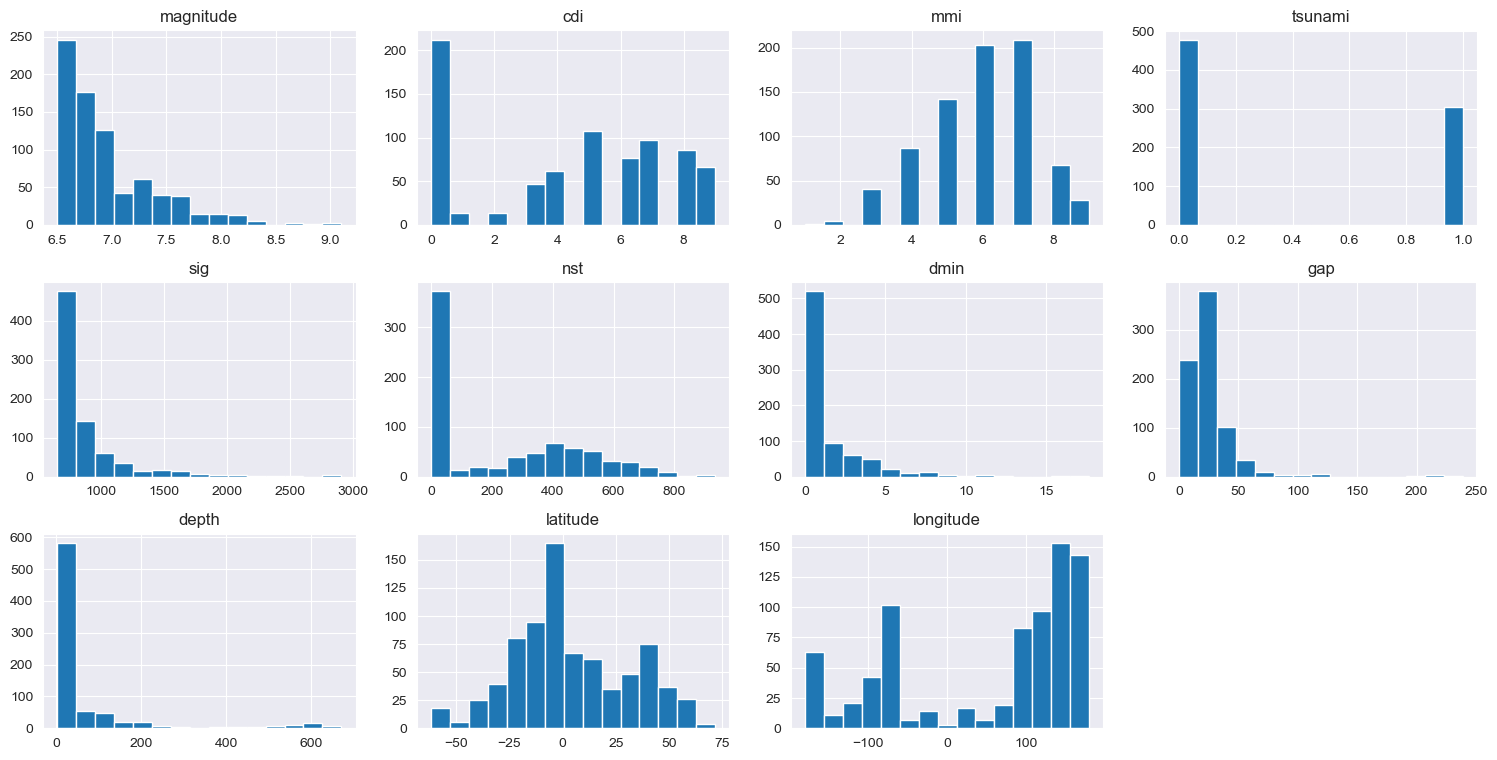

In [70]:
df.hist(bins=15, figsize=(15,10), layout=(4,4))
plt.tight_layout()
plt.show()

Figure 1: Histograms of Numerical Features

This histogram visualization reveals several important insights about the dataset.
- tsunami is a binary variable with most values being 0 (no tsunami).
- left skewed distributions appear common for `magnitude, sig, cdi, mmi, nst, dmin, gap, and depth.`
    - This suggests that most earthquakes in this dataset are of lower magnitude and general impact with a smaller collection of high magnitude and high impact events, these are likely to be the larger scale earthquakes.

In [71]:
df.sample(16)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
166,"M 7.1 - 136 km W of Iñapari, Peru",7.10,24-08-2018 09:04,0,3,green,0,776,us,0,3.770,12.0,mww,630.00,-11.0355,-70.8284,"Iñapari, Peru",South America,Peru
296,"M 6.8 - 117 km SSE of Ugashik, Alaska",6.80,29-05-2015 07:00,5,6,green,1,762,ak,0,0.000,0.0,mw,72.60,56.5940,-156.4300,"Ugashik, Alaska",NaN,NaN
191,"M 6.5 - 67 km WSW of Angoram, Papua New Guinea",6.50,07-11-2017 21:26,6,5,green,1,661,us,0,4.449,10.0,mww,110.57,-4.2433,143.4850,"Angoram, Papua New Guinea",NaN,Papua New Guinea
518,"M 7.0 - 70 km SE of Katsuren-haebaru, Japan",7.00,26-02-2010 20:31,6,6,NaN,0,1180,us,487,0.000,15.7,mwc,25.00,25.9300,128.4250,"Katsuren-haebaru, Japan",NaN,NaN
321,"M 6.5 - 123 km WNW of Tobelo, Indonesia",6.50,21-11-2014 10:10,5,5,green,1,652,us,0,1.549,9.0,mww,35.00,2.2999,127.0560,"Tobelo, Indonesia",NaN,Indonesia
65,"M 7.3 - Southern Qinghai, China",7.30,21-05-2021 18:04,9,9,orange,0,1025,us,0,4.655,9.0,mww,10.00,34.5861,98.2551,"Southern Qinghai, China",Asia,People's Republic of China
187,"M 7.0 - 85 km ENE of Tadine, New Caledonia",7.00,19-11-2017 22:43,4,6,green,1,771,us,0,0.617,14.0,mww,10.00,-21.3246,168.6710,"Tadine, New Caledonia",NaN,NaN
446,"M 6.7 - 2 km NNE of Jimalalud, Philippines",6.70,06-02-2012 03:49,9,7,NaN,0,1551,us,572,0.000,11.1,mww,11.00,9.9990,123.2060,"Jimalalud, Philippines",NaN,Philippines
492,"M 7.0 - 72 km ESE of Kimbe, Papua New Guinea",7.00,04-08-2010 22:01,4,6,NaN,0,757,us,396,0.000,12.7,mww,44.00,-5.7460,150.7650,"Kimbe, Papua New Guinea",NaN,Papua New Guinea
401,"M 6.6 - 98 km W of Panguna, Papua New Guinea",6.60,14-04-2013 01:32,0,5,green,1,670,us,491,0.000,11.5,mww,31.00,-6.4750,154.6070,"Panguna, Papua New Guinea",NaN,NaN


#### Features / Feature columns

`magnitude`, `cdi`, `mmi`, `sig`, `nst`, `dmin`, `gap`, `depth`, `latitude`, `longitude`,
`title`, `date_time`, `alert`, `net`, `magType`, `location`, `continent`, `country`

Further analysis is needed to confirm these feature types and their relevance to tsunami prediction.

---

#### Target Variable / Target Column

**`tsunami`** – Tsunami occurrence indicator (`1 = tsunami`, `0 = no tsunami`)

Our target binary numerical variable represents whether a tsunami occurred following an earthquake event. The importance of this target If we model and predict this variable accurately, it could have significant implications for disaster preparedness and mitigation. For example, if we can predict tsunami occurrence based on earthquake characteristics, we can issue timely warnings to coastal communities, potentially saving lives and reducing property damage.

#### Statistical Summary


In [72]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,0.388747,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199
std,0.445514,3.169939,1.462724,0.487778,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886
min,6.500000,0.000000,1.000000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.000000,0.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050
50%,6.800000,5.000000,6.000000,0.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000
75%,7.100000,7.000000,7.000000,1.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000
max,9.100000,9.000000,9.000000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


In [73]:
print(f'Dataset Shape: {df.shape}')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print('Column Names:', df.columns.tolist())

Dataset Shape: (782, 19)
Rows: 782, Columns: 19
Column Names: ['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']


### Data Types


In [74]:
unique_values = df.nunique()
print(f'Unique values per column:\n{unique_values}')
country_unique_variables_before_imputation = df['country'].nunique()

Unique values per column:
title        768
magnitude     24
date_time    773
cdi           10
mmi            9
alert          4
tsunami        2
sig          339
net           11
nst          312
dmin         369
gap          256
magType        9
depth        303
latitude     778
longitude    777
location     413
continent      6
country       49
dtype: int64


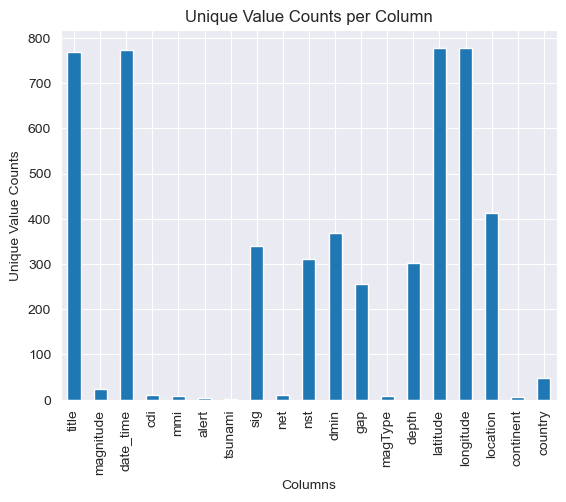

In [75]:
df.nunique(axis=0).plot(kind='bar')
plt.title('Unique Value Counts per Column')
plt.xlabel('Columns')
plt.ylabel('Unique Value Counts')
plt.show()

Figure 2: This chart shows the number of unique values for each dataset column. This is useful for identifying categorical features (which typically have a limited number of unique values) versus numerical features (which often have a larger number of unique values).

In [76]:
print(df.dtypes)

title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
net           object
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object


When deciding if a variable is categorical or numerical we considered that:
- Numerical variables typically have a large number of unique values (e.g., more than 15-20 unique values).
- Categorical variables usually have a limited number of unique values (e.g., less than 15-20 unique values) and often represent distinct categories or groups.
- Categorical variables can also be identified by their data type (e.g., 'object' in pandas).
- Textual data can be identified by sampling the data and looking at the values.

 According to the USGS, `mmi` and `cdi` are both intensity scales that measure the effects of an earthquake, while `magnitude` measures the energy released. `magnitude` will therefore be treated numerical as it represents a continuous scale of energy release but `cdi` and `mmi` will be treated as ordered categorical features as they represent discrete intensity levels.
(United States Geological Survey, no date; Wald et al., 2011; United States Geological Survey, 1989)


 `title` and `location` are unstructured text features because they are of object data type but have a higher relative unique value counts (shown in bar chart) of more free-form text data. `date_time` is a datetime feature.  Our target variable `tsunami` is a binary numerical variable having only has 2 unique values (0 and 1).




| Types of data               | Features                                               |
|-----------------------------|--------------------------------------------------------|
| Numerical Features          | `magnitude`, `sig`, `nst`, `dmin`, `gap`, `depth`, `latitude`, `longitude` |
| Categorical Features        | `cdi`, `mmi`                                          |
| Datetime Feature            | `date_time`                                           |
| Categorical Text Feature   | `alert`, `net`, `magType`, `continent`, `country`          |
| Unstructured Text Feature   | `title`, `location`                                   |
| Target Variable (Binary Numerical) | `tsunami`                                             |

Figure 3: Data Types of Features and Target Variable

### Mapping my task to ML problem type

The goal is to predict the occurrence of tsunamis following earthquakes based on the characteristics of the seismic events. Given the target variable `tsunami` is binary (1 = tsunami, 0 = no tsunami), indicating whether a tsunami occurred after an earthquake event, this is a **binary classification** problem. Using the features of the earthquakes we will classify whether a tsunami will occur (1) or not (0) following an earthquake event.

#### Key features that will likely be important for predicting tsunami occurrence and there meaning

Observing (Chauhan, 2025, About Dataset), the following features stand out as particularly relevant for predicting tsunamis :

- `magnitude`: Higher magnitude earthquakes are more likely to generate tsunamis.
- `latitude` and `longitude`: The geographical location of the earthquake can influence tsunami risk, especially near coastal areas.
- `cdi` and `mmi`: Higher intensity levels may correlate with tsunami generation.
- `sig`: More significant earthquakes may have a higher likelihood of causing tsunamis.



### Missing Values


In [77]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


In [78]:
place_holders = [-9999, 9999, np.inf, -np.inf, 'nan', 'NaN', 'NA', 'null', 'NULL', '']
print(df.isin(place_holders).sum().sum() + df.isnull().sum().sum())

1246


In [79]:
#percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
print(f'Percentage of missing values per column:\n{missing_percentage}')

Percentage of missing values per column:
alert        46.930946
location      0.639386
continent    73.657289
country      38.107417
dtype: float64


In [80]:
missing_values_datatypes = df[missing_percentage.index].dtypes
print(f'Data types of columns with missing values:\n{missing_values_datatypes}')

Data types of columns with missing values:
alert        object
location     object
continent    object
country      object
dtype: object


In [81]:
df[missing_percentage.index].sample(16)

,alert,location,continent,country
376,orange,"Khuzdar, Pakistan",Asia,Pakistan
606,NaN,"Gizo, Solomon Islands",NaN,Solomon Islands
440,green,off the west coast of northern Sumatra,NaN,NaN
8,yellow,"Aguililla, Mexico",North America,Mexico
438,NaN,"San Luis, Mexico",North America,Mexico
304,green,"Kokopo, Papua New Guinea",NaN,Papua New Guinea
341,green,"Punta de Burica, Panama",NaN,NaN
470,NaN,"Helio García Alfaro, Mexico",NaN,Mexico
269,green,"Iñapari, Peru",South America,Peru
611,NaN,the Kuril Islands,NaN,NaN



Referencing figure 3, the columns missing values are either unstructured text features (`location`, `country`) or categorical text features (`alert`,`continent`). There are no missing values in numerical features.

#### Understanding missing data patterns

| **Feature**              | **Type of Missingness**           | **Reason / Explanation**                                                                                                                                                                                                                 |
|---------------------------|----------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Alert Level**           | Missing Not At Random (MNAR)     | Missingness is related to the unobserved value itself — less significant earthquakes are less likely to have an alert level assigned.                                                              |
| **Location**              | Missing At Random (MAR)          | Missingness depends on other observed variables (latitude and longitude). Location may not be recorded because coordinates are already available.                                                  |
| **Country**               | Missing At Random (MAR)          | Missingness is related to latitude and longitude data — the country may be inferred from coordinates, making direct recording unnecessary.                                                         |
| **Continent**             | Missing At Random (MAR)          | Missingness depends on other observed information (such as latitude, longitude, or country) and is not directly related to the continent value itself.                                              |



#### Alert missing values imputation strategy

<Axes: xlabel='alert'>

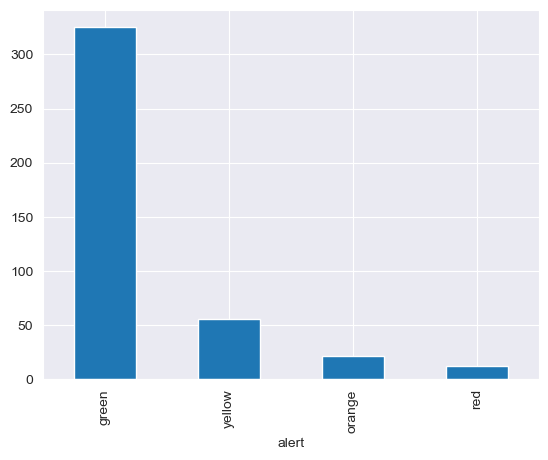

In [82]:
#get unique values for alert column
df['alert'].value_counts().plot(kind='bar')

This charft tells us a few important things about the `alert` column:
- The most common alert level is "green", indicating low severity earthquakes.
- It has a small number of fixed categories (green, yellow, orange, red) which should make imputation easier.



The dataset has a left skewed distribution of earthquake magnitudes and impacts (figure 1), hence the lower severity alert levels (green and yellow) are more common than higher severity levels (orange and red). This strongly suggests that alert levels are related to earthquake characteristics which we can leverage for imputation.

`alert` is an ordinal categorical variable where the levels have a natural order of severity: green < yellow < orange < red (United States Geological Survey, no date, section “PAGER Scientific Background”).



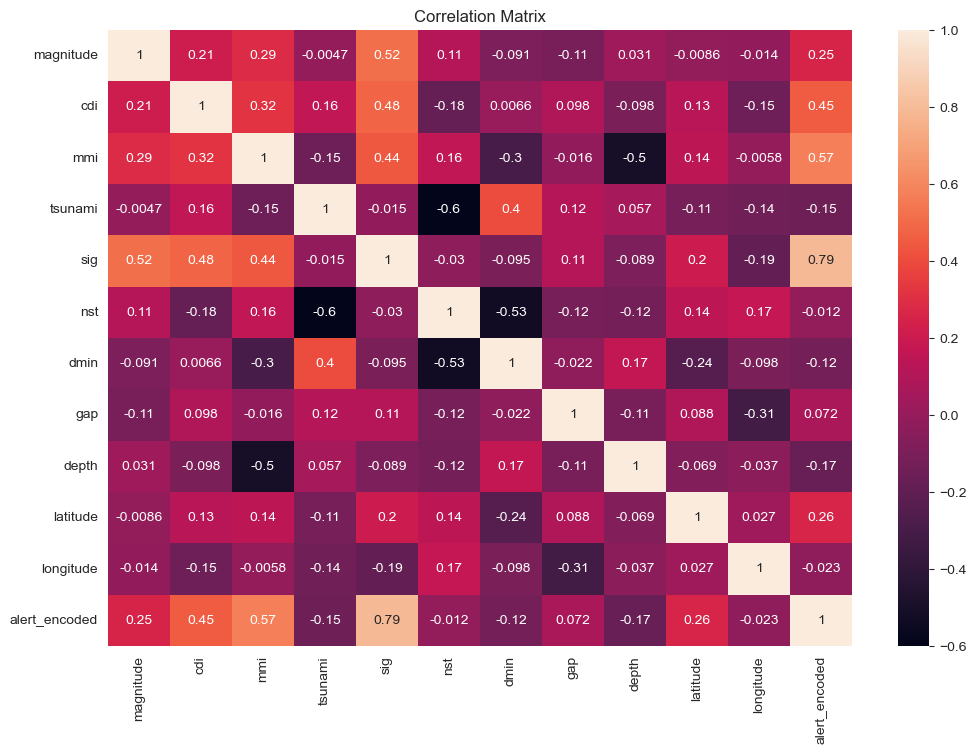

In [83]:
#ordinal encoding of alert levels
alert_order = {'green': 1, 'yellow': 2, 'orange': 3, 'red': 4}
df_temp = df.copy()
df_temp['alert_encoded'] = df_temp['alert'].map(alert_order)
numerical_cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_temp[numerical_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

Studying the correlation matrix, we can see there is a strong correlation between `alert` and `sig` (0.79) so we will use this correlation to impute missing alert levels based on the `sig` value of each earthquake event.

This will be a rule based / conditional imputation strategy where we calculate the mean `sig` value for each alert level and use those thresholds to impute missing alert levels based on the `sig` value of each earthquake event.

In [84]:
print(df.groupby('alert').agg({
    'sig': ['mean']
}).sig)

               mean
alert              
green    773.224615
orange  1382.136364
red     2475.000000
yellow  1047.696429


In [85]:
alert_thresholds = df.groupby('alert').agg({
    'sig': ['mean']
}).sig

green_threshold = alert_thresholds.loc['green', 'mean'] #index by alert level, get column 'mean'
yellow_threshold = alert_thresholds.loc['yellow', 'mean']
orange_threshold = alert_thresholds.loc['orange', 'mean']
red_threshold = alert_thresholds.loc['red', 'mean']

#Order of alert levels: red, orange, yellow, green - source: (United States Geological Survey, no date, section “PAGER Scientific Background”)

def impute_alert(row):
    if pd.isnull(row['alert']):
        if row['magnitude'] >= red_threshold:
            return 'red'
        elif row['magnitude'] >= orange_threshold:
            return 'orange'
        elif row['magnitude'] >= yellow_threshold:
            return 'yellow'
        else:
            return 'green'
    else:
        return row['alert']
df['alert'] = df.apply(impute_alert, axis=1)
print(f'Missing values in alert column after imputation: {df["alert"].isnull().sum()}')

Missing values in alert column after imputation: 0


#### Location missing values imputation strategy

<Axes: >

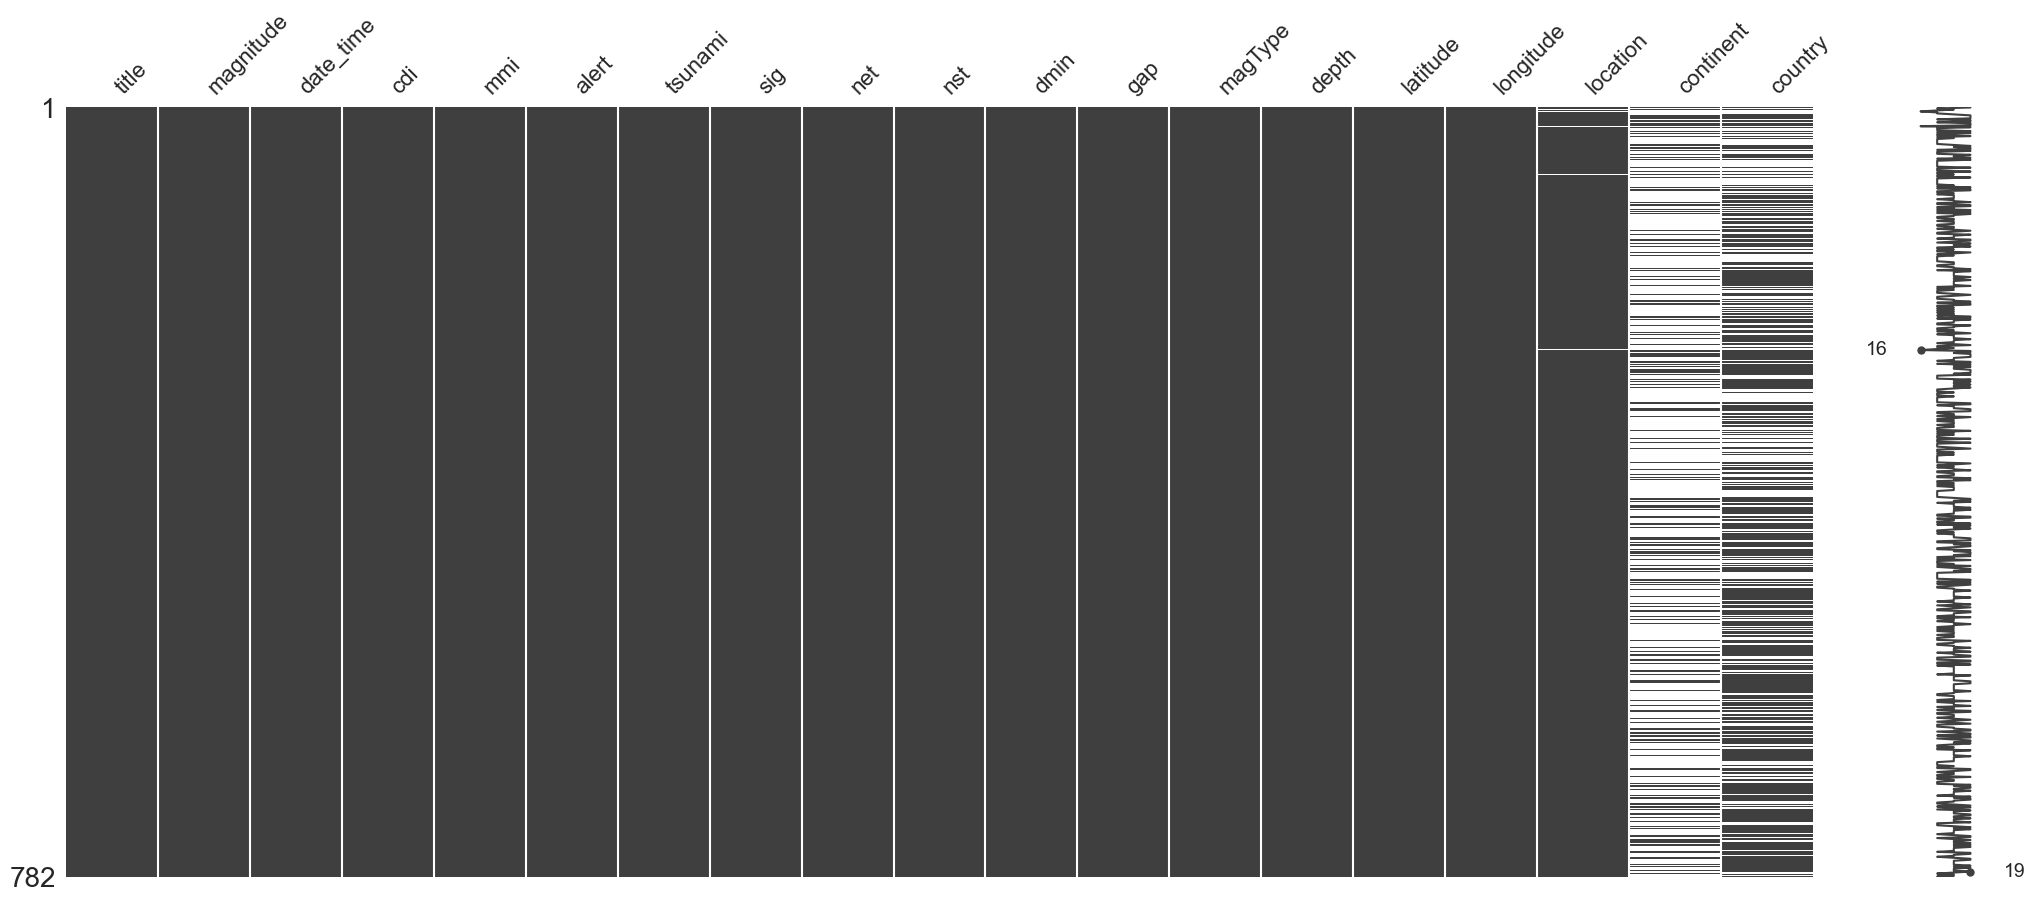

In [86]:
msno.matrix(df)

`Location` is closely related to the `country` feature as it describes the area within the country. `location` is an unstructured text feature and `country` categorical text feature and, given they are the same type of data, we can use one to impute missing values in the other.

The true location values will have a more precise description of the area within the country but, using this strategy, is better than having no location information at all. This is possible because the missing matrix shows that in many cases where `location` is missing, `country` is present.


This is another example of rule based / conditional imputation but this time based on the categorical relationship between the `location` and `country` features.



In [87]:
print(f'Missing values in location column before imputation: {df["location"].isnull().sum()}')
def impute_location(row):
    if pd.isnull(row['location']):
        if not pd.isnull(row['country']):
            return f'{row["country"]}'
        else:
            return np.nan # cannot impute location
    else:
        return row['location']
#apply the imputation function
df['location'] = df.apply(impute_location, axis=1)
#verify no more missing values in location column
print(f'Missing values in location column after imputation: {df["location"].isnull().sum()}')

Missing values in location column before imputation: 5
Missing values in location column after imputation: 3


In [88]:
df = df.dropna(subset=['location'])
print('Data shape after dropping rows with missing location:', df.shape)

Data shape after dropping rows with missing location: (779, 19)


The remaining missing values in the location column are those where both location and country were missing so we could not impute anything meaningful and have dropped these rows from the dataset. This will remove 3 rows from the dataset, leaving us with 779 samples.

In [89]:
print(df.location.sample(15))

297        Kirakira, Solomon Islands
113             Kisante, Philippines
106                 Kuril’sk, Russia
166                    Iñapari, Peru
156          Severo-Kuril’sk, Russia
683        Kirakira, Solomon Islands
83          Néon Karlovásion, Greece
71                 Ishinomaki, Japan
252                 Mawlaik, Myanmar
262           Sarangani, Philippines
196             Attu Station, Alaska
662    Pulau-Pulau Talaud, Indonesia
470      Helio García Alfaro, Mexico
627                    Pangai, Tonga
746                    Calama, Chile
Name: location, dtype: object


#### Country missing values imputation strategy

In [90]:
coma_count = df['location'].str.contains(',').sum()
print(f'Percentage of locations with a comma: {(coma_count / len(df)) * 100:.2f}%')

Percentage of locations with a comma: 91.40%


The random samples above show many of the location entries contain a comma, indicating both a specific area and the country name (e.g., "Los Angeles, USA"). This infomation can help us populate missing country values from the location column by taking the substring after the comma as the country and, given the quantity of missing country values (298), this will introduce some multi-collinearity.

I believe this is acceptable as having some country information is better than none at all for our modeling and, similar to using the `country` feature to impute missing `location` values, we can use the `location` feature to impute missing `country` values.

This is another example of rule based / conditional imputation based on the relationship between the `location` and `country` features.

In [91]:
print(f'Missing values in country column before imputation: {df["country"].isnull().sum()}')
def impute_country(row):
    if pd.isnull(row['country']):
        if ',' in row['location']:
            return row['location'].split(',')[-1].strip() # extract country from location using the last part after comma
        else:
            return np.nan # cannot impute country
    else:
        return row['country']
#apply the imputation function

#verify no more missing values in country column
df['country'] = df.apply(impute_country, axis=1)
print(f'Missing values in country column after imputation: {df["country"].isnull().sum()}')

Missing values in country column before imputation: 295
Missing values in country column after imputation: 42


In [92]:
missing_country_locations = df[df['country'].isnull()]['location']
print(f'Locations with missing country values:\n{missing_country_locations}')

Locations with missing country values:
5                            the Fiji Islands
6                            the Fiji Islands
15                       the Kermadec Islands
22                        the Loyalty Islands
28                           the Fiji Islands
30                    Kermadec Islands region
45                             Vanuatu region
46                             Vanuatu region
52              South Sandwich Islands region
56              South Sandwich Islands region
57              South Sandwich Islands region
67                 Mauritius - Reunion region
73                    Kermadec Islands region
78                        the Loyalty Islands
85                 central Mid-Atlantic Ridge
88                 central Mid-Atlantic Ridge
97                       the Kermadec Islands
137              Prince Edward Islands region
160                          the Fiji Islands
161                   Kermadec Islands region
186                      Bouvet Island re

Many of the 42 samples without country data are small islands, territories, ocean regions, or disputed areas.

Having analysed this data, i'm confident these values represent similar value to countries and will therefore impute these missing country values with the location value itself for these instances.


In [93]:
df['country'] = df['country'].fillna(df['location'])
#verify no more missing values in country column
print(f'Missing values in country column after final imputation: {df["country"].isnull().sum()}')

Missing values in country column after final imputation: 0


#### Continent missing values imputation strategy

<Axes: >

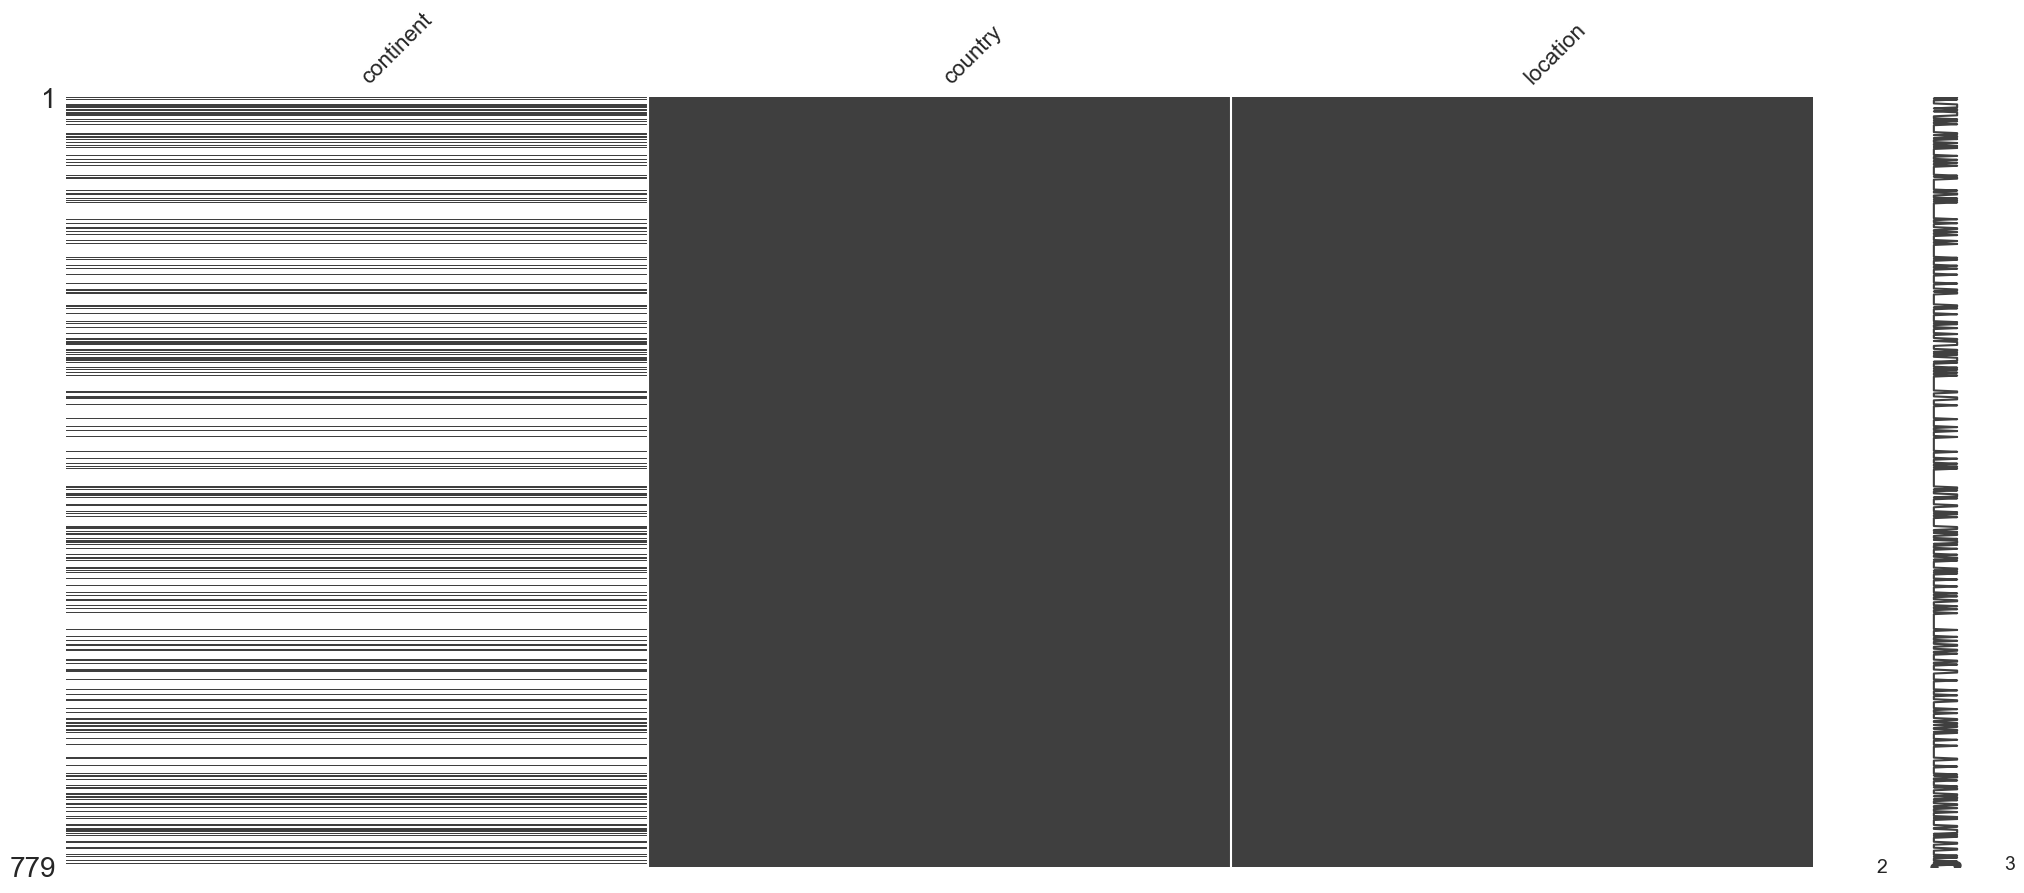

In [94]:
msno.matrix(df[['continent', 'country', 'location']])

Data missing from the `contient` column is 73%. Given this high level of missingness, it is therefore more practical to drop the 'continent' column entirely from the dataset rather than attempting to impute the missing values. Imputing such a large proportion of missing data could introduce significant bias and uncertainty into the dataset.


In [95]:
df = df.drop(columns=['continent'])
print(df.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'country'],
      dtype='object')


#### Visualizing missing data pattern after imputation

In [96]:
total_missing_after = df.isnull().sum().sum()
print(f'Total missing values after imputation: {total_missing_after}')

Total missing values after imputation: 0


In [97]:
X, y = df.drop(columns='tsunami'), df['tsunami']
X.shape, y.shape, X.columns

((779, 17),
 (779,),
 Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'sig', 'net',
        'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude',
        'location', 'country'],
       dtype='object'))

X is our new Dataframe containing all features except the target variable `tsunami`, and y is a Series containing target variable `tsunami` which we will predict.

X a fully imputed feature set with no missing values, and y `tsunami` didn't have any missing values to begin with.

### Encoding Categorical Features and Text Features

We must encode categorical features into numerical format before modeling as most machine learning algorithms require numerical input. We will use one-hot encoding for nominal categorical features and ordinal encoding for ordinal categorical features (figure 3)

During our feature type identification earlier, we determined that `cdi` and `mmi` are ordinal categorical features as they represent intensity levels with a natural order of severity and have a limited number of unique values (United States Geological Survey (USGS), 1989; Wald et al., 2011). These features do not need encoding as they are already in numerical format.

`alert`, is also an ordinal categorical variable so we will apply ordinal encoding as it is currently in a categorical text format and needs to be converted to numerical format for modeling.

In [98]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_features = ['alert']
ordinal_encoder = OrdinalEncoder(categories=[['green', 'yellow', 'orange', 'red']])
X[ordinal_features] = ordinal_encoder.fit_transform(X[ordinal_features])

We must also encode our other categorical text features: `net`, `magType`,`Contient`, and `country` (figure 3). These are nominal categorical variables as there is no inherent order to the categories they represent. We will use one-hot encoding to convert these nominal categorical features into numerical format by creating binary indicator variables for each category.

In [99]:
#one-hot encoding of nominal categorical features
columns_before = X.shape[1]
nominal_features = ['net', 'magType']
X = pd.get_dummies(X, columns=nominal_features, drop_first=True)
columns_after = X.shape[1]

49
87


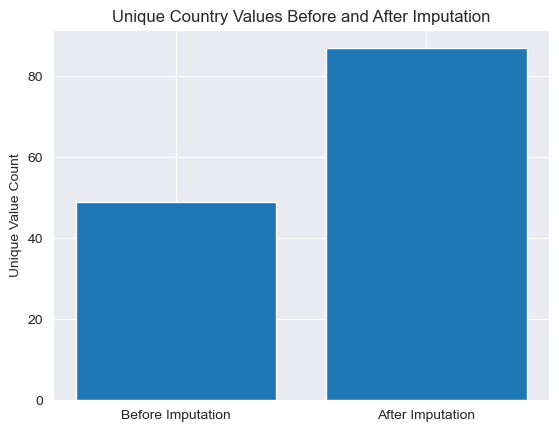

In [100]:
print(country_unique_variables_before_imputation)
print(df.country.nunique())
plt.bar(['Before Imputation', 'After Imputation'], [country_unique_variables_before_imputation, df.country.nunique()])
plt.title('Unique Country Values Before and After Imputation')
plt.ylabel('Unique Value Count')
plt.show()

Having imputed missing values in the `country` feature earlier its unique value count has grown from 49 to 87 unique values. This is expected as we filled in missing country values using location data, which introduced new country names that were not present before imputation.

As country is a nominal categorical variable, we would need to hot-one encode it, this would create 87 new columns. This will greatly increase the dimensions in our dataset, likely creating overfitting. We are also aware that 91.4% of location values likely contain country information anyway, so I will drop this feature.

In [101]:
X = X.drop(columns=['country'])
X

,title,magnitude,date_time,cdi,mmi,alert,sig,nst,dmin,gap,...,net_us,net_uw,magType_mb,magType_md,magType_ml,magType_ms,magType_mw,magType_mwb,magType_mwc,magType_mww
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,0.0,768,117,0.509,17.0,...,True,False,False,False,False,False,False,False,False,True
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,0.0,735,99,2.229,34.0,...,True,False,False,False,False,False,False,False,False,True
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,0.0,755,147,3.125,18.0,...,True,False,False,False,False,False,False,False,False,True
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,0.0,833,149,1.865,21.0,...,True,False,False,False,False,False,False,False,False,True
5,M 7.0 - south of the Fiji Islands,7.0,09-11-2022 09:51,4,3,0.0,755,142,4.578,26.0,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,0.0,912,427,0.000,0.0,...,True,False,False,False,False,False,False,False,True,False
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,0.0,745,0,0.000,0.0,...,False,False,False,False,False,False,True,False,False,False
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,0.0,776,372,0.000,0.0,...,True,False,False,False,False,False,False,True,False,False
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,0.0,711,64,0.000,0.0,...,True,False,False,False,False,False,False,False,True,False


Now we must process our unstructured text features: `title` and `location` (figure 3). These features contain free-form text data that cannot be directly used in most ML models so we will need to convert this text data into numerical format using text vectorization techniques.


In [102]:
import gensim.downloader as api
word2vec_model = api.load('glove-wiki-gigaword-50') #pre-trained Word2Vec model with 50-dimensional vectors

def average_word_vectors(text, model):
    words = str(text).lower().split()
    vectors = []
    for words in words:
        if words in model: #When you iterate through model, you get the words in the vocabulary (it must have a custom __iter__ method)
            vectors.append(model[words])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

#apply the averaging function to title and location columns
title_vectors = X['title'].apply(lambda x: average_word_vectors(x, word2vec_model))
location_vectors = X['location'].apply(lambda x: average_word_vectors(x, word2vec_model))
title_df = pd.DataFrame(title_vectors.tolist(), index=X.index).add_prefix('title_vec_') #take index from original X to align rows
location_df = pd.DataFrame(location_vectors.tolist(), index=X.index).add_prefix('location_vec_')
X = pd.concat([X, title_df, location_df], axis=1)
X = X.drop(columns=['title', 'location'])
X

,magnitude,date_time,cdi,mmi,alert,sig,nst,dmin,gap,depth,...,location_vec_40,location_vec_41,location_vec_42,location_vec_43,location_vec_44,location_vec_45,location_vec_46,location_vec_47,location_vec_48,location_vec_49
0,7.0,22-11-2022 02:03,8,7,0.0,768,117,0.509,17.0,14.0,...,-0.413625,1.011540,0.835310,-0.672395,-1.054485,0.468645,-0.376000,-0.737735,-0.421065,-0.443805
1,6.9,18-11-2022 13:37,4,4,0.0,735,99,2.229,34.0,25.0,...,-1.397400,0.328640,0.903000,-1.181100,0.236450,1.036200,-0.586330,0.309870,0.325110,-1.210100
2,7.0,12-11-2022 07:09,3,3,0.0,755,147,3.125,18.0,579.0,...,-0.678180,0.542310,0.366070,-0.350280,-0.664370,1.286700,-0.978370,0.141160,0.803460,-0.977450
3,7.3,11-11-2022 10:48,5,5,0.0,833,149,1.865,21.0,37.0,...,-0.083787,0.562320,0.343680,-0.498550,-0.811640,1.716400,-0.491980,0.052259,0.706380,-0.809750
5,7.0,09-11-2022 09:51,4,3,0.0,755,142,4.578,26.0,660.0,...,-0.508930,0.422533,0.538463,-0.348069,-0.877760,0.618010,-0.535445,-0.326447,0.172120,-0.906737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,7.7,13-01-2001 17:33,0,8,0.0,912,427,0.000,0.0,60.0,...,-0.525199,0.588573,0.626350,-1.385473,-0.272928,-0.331966,-0.926685,-0.707303,0.474065,-0.023720
778,6.9,10-01-2001 16:02,5,7,0.0,745,0,0.000,0.0,36.4,...,-0.602380,0.546825,0.408775,0.057960,-0.438345,0.065940,-0.293385,-0.393100,-0.215465,-0.072315
779,7.1,09-01-2001 16:49,0,7,0.0,776,372,0.000,0.0,103.0,...,-0.660620,0.921090,0.486700,-1.248600,-1.001100,0.611220,-0.338700,0.311190,0.707830,-0.753600
780,6.8,01-01-2001 08:54,0,5,0.0,711,64,0.000,0.0,33.0,...,-1.447600,0.193520,0.699930,-1.508400,-0.045248,0.242790,-0.459550,-0.234900,0.175560,-0.527280


#### Not all models require only numerical input features.
 decsion trees and ensemble models can handle categorical features directly. However, many popular machine learning algorithms, such as logistic regression require numerical input features. So in order to do a fair comparision later on between different model types, we will convert all categorical features to numerical format now.

In [103]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f'Object type columns in X: {object_columns}')

Object type columns in X: ['date_time']


In [104]:
X['time'] = pd.DataFrame({'time': pd.to_datetime(X['date_time'])})
X['time'] = pd.to_datetime(X['time']).astype(int)/ 10**9 #unix timestamp
X = X.drop(columns=['date_time'])

/var/folders/ch/bfx06mdj29ndjk1wx8vb4pz00000gn/T/ipykernel_59103/2294119898.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X['time'] = pd.DataFrame({'time': pd.to_datetime(X['date_time'])})


(AlwaysSunny, 2019)

In [105]:
object_columns = X.select_dtypes(include=['object']).columns.tolist()
print(f'Object type columns in X: {object_columns}')
datatime_columns = X.select_dtypes(include=['datetime64[ns]']).columns.tolist()
print(f'Datetime type columns in X: {datatime_columns}')

Object type columns in X: []
Datetime type columns in X: []


### Further data visualization and issue identification

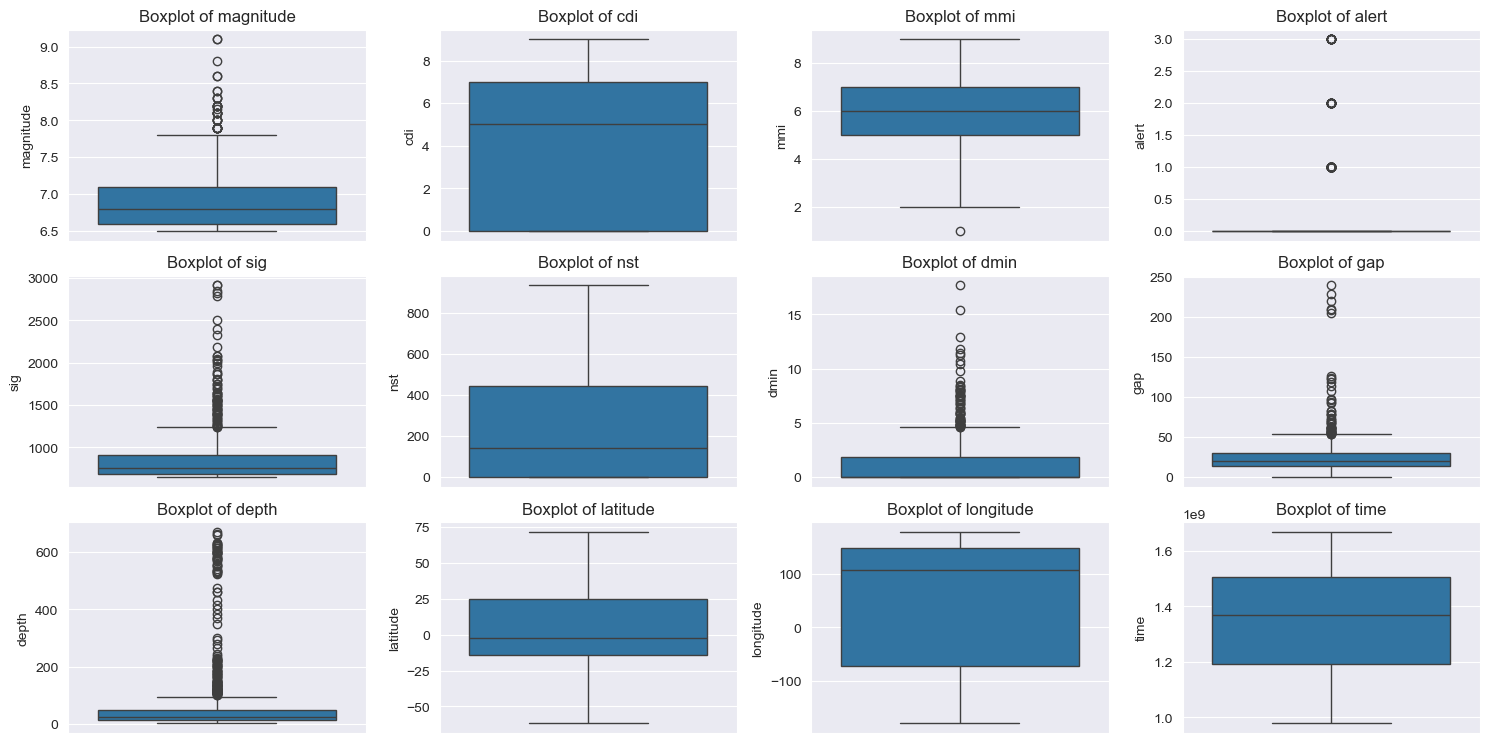

In [106]:
non_encoded_render = [c for c in X.columns if '_' not in c] #exclude vectorized text features for boxplots because they have many dimensions
plt.figure(figsize=(15,10))
for i, col in enumerate(non_encoded_render):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=X[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

#### Extreme outliers issue

From these boxplots we can see that several features have significant outliers, including `magnitude`, `sig`, `nst`, `dmin`, `gap`, and `depth`. These outliers could potentially impact model performance, especially for algorithms sensitive to extreme values like logistic regression and neural networks.

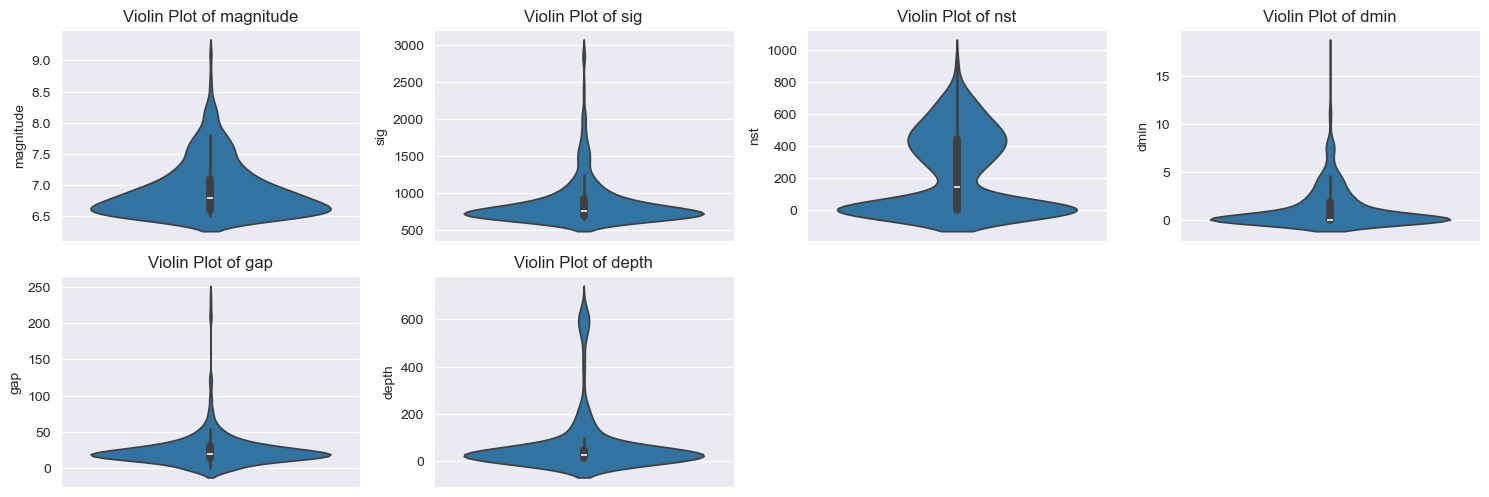

In [107]:
features_of_interest = ['magnitude', 'sig', 'nst', 'dmin', 'gap', 'depth']
plt.figure(figsize=(15,10))
for i, col in enumerate(features_of_interest):
    plt.subplot(4, 4, i + 1)
    sns.violinplot(y=X[col])
    plt.title(f'Violin Plot of {col}')
plt.tight_layout()
plt.show()

Our various violin plots above confirm the presence of extreme outliers in these features, as indicated by the long tails extending from the main distribution. We can see that the majority of data points are concentrated in a smaller range, while a few extreme values stretch far beyond this range, indicating the presence of outliers.

In [108]:
for col in features_of_interest:
    min_value = X[col].min()
    print(f'Minimum value in {col}: {min_value}')

Minimum value in magnitude: 6.5
Minimum value in sig: 650
Minimum value in nst: 0
Minimum value in dmin: 0.0
Minimum value in gap: 0.0
Minimum value in depth: 2.7



We will use log1p transformation which is log(1 + x). This is useful because it can handle zero values without resulting in undefined values, and it compresses the scale of the data, reducing the impact of extreme outliers while preserving the relative differences between values.

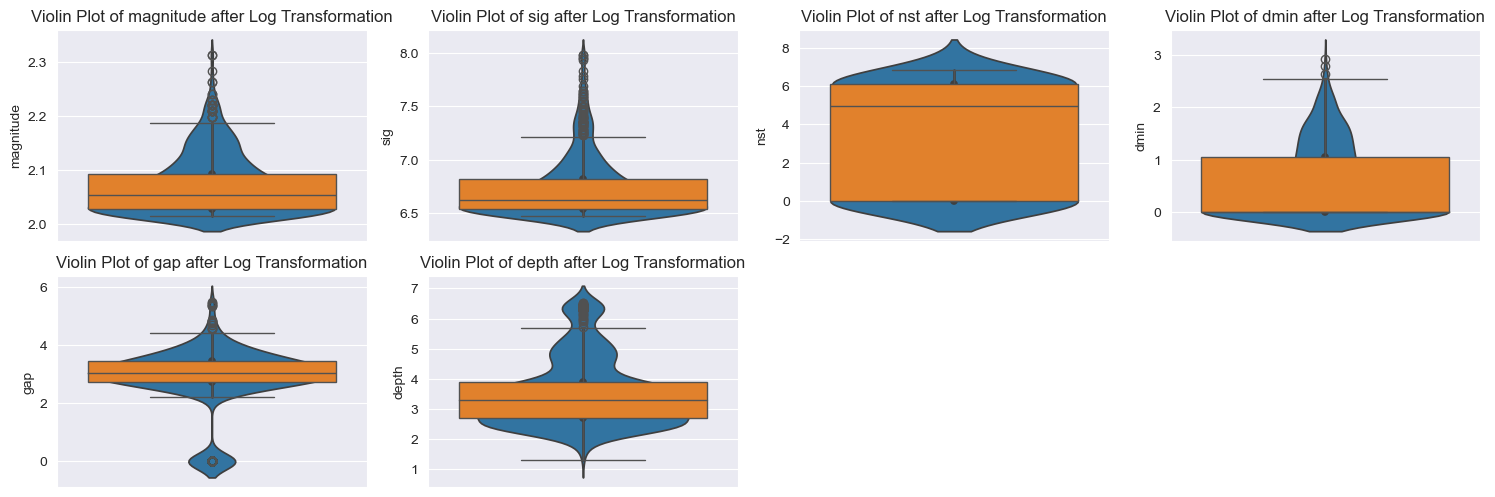

In [109]:
X[features_of_interest] = X[features_of_interest].apply(lambda x: np.log1p(x))
plt.figure(figsize=(15,10))
for i, col in enumerate(features_of_interest):
    plt.subplot(4, 4, i + 1)
    sns.violinplot(y=X[col])
    sns.boxplot(y=X[col])
    plt.title(f'Violin Plot of {col} after Log Transformation')
plt.tight_layout()
plt.show()

Figure 3: Violin Plots of Features After Log Transformation

We can see that after log transformation, the distributions of these features are more compact, and the extreme outliers have been reduced in influence. The main body of the data is now more prominent, with a large portion of the data concentrated in a smaller range, making it easier for models to learn from the data without being overly influenced by extreme values.

Most of our values are still concentrated towards the lower end of the scale, which is expected given the left-skewed distributions we observed earlier in figure 1. However, the log transformation has helped to mitigate the impact of extreme outliers, making the data more suitable for modeling and addressed this skew to an extent.

In [110]:
print(X.isnull().sum().sum())

0


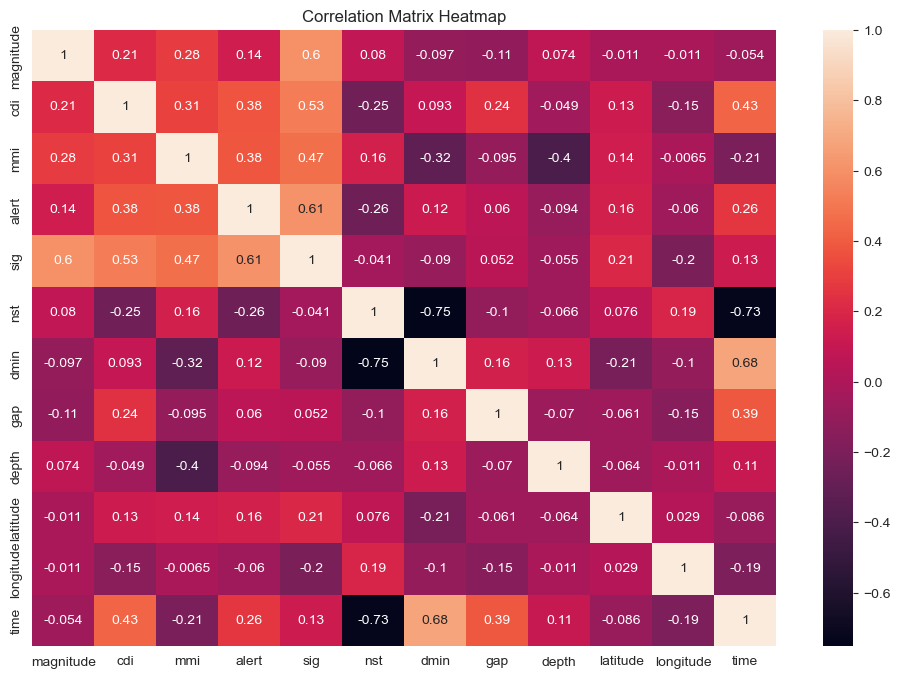

In [111]:
#Correlation matrix heatmap
corr_matrix = X[non_encoded_render].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

None of our features seem too highly correlated (above 0.9) so we don't need to drop any features due to multicollinearity.

In [112]:
#check for duplicate rows
duplicate_rows = X.duplicated().sum()
print(f'Number of duplicate rows in X: {duplicate_rows}')

Number of duplicate rows in X: 0


### Scaling our features

We must scale our features which are now all numerical to ensure they are on a comparable scale. This is important because features with larger ranges can dominate the learning process and lead to unstable model training and convergence issues.

We can avoid these issues by scaling our features to a similar range, ensuring that no single feature dominates the learning process and allowing the model to learn from all features effectively without being influenced by their original scales.

We will be using StandardScalar, which is z-score normalization, to scale our features. This scales the features to have a mean of 0 and a standard deviation of 1.

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [114]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #This is z-score normalization
scaler = scaler.fit(X_train)

In [115]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns, index=y_train.index)
X_test = pd.DataFrame(X_test, columns=X.columns, index=y_test.index)

### Feature Reduction


In [116]:
df[['country', 'location','title']]

,country,location,title
0,Solomon Islands,"Malango, Solomon Islands","M 7.0 - 18 km SW of Malango, Solomon Islands"
1,Indonesia,"Bengkulu, Indonesia","M 6.9 - 204 km SW of Bengkulu, Indonesia"
2,Fiji,Fiji,M 7.0 -
3,Tonga,"Neiafu, Tonga","M 7.3 - 205 km ESE of Neiafu, Tonga"
5,the Fiji Islands,the Fiji Islands,M 7.0 - south of the Fiji Islands
...,...,...,...
777,El Salvador,"Puerto El Triunfo, El Salvador","M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal..."
778,Alaska,"Old Harbor, Alaska","M 6.9 - 47 km S of Old Harbor, Alaska"
779,Vanuatu,"Port-Olry, Vanuatu","M 7.1 - 16 km NE of Port-Olry, Vanuatu"
780,Philippines,"Mindanao, Philippines","M 6.8 - Mindanao, Philippines"


In [117]:
X_train = X_train.loc[:, ~X_train.columns.str.startswith('title_')]
X_test = X_test.loc[:, ~X_test.columns.str.startswith('title_')]
X
#TODO: GPT REF

,magnitude,cdi,mmi,alert,sig,nst,dmin,gap,depth,latitude,...,location_vec_41,location_vec_42,location_vec_43,location_vec_44,location_vec_45,location_vec_46,location_vec_47,location_vec_48,location_vec_49,time
0,2.079442,8,7,0.0,6.645091,4.770685,0.411447,2.890372,2.708050,-9.7963,...,1.011540,0.835310,-0.672395,-1.054485,0.468645,-0.376000,-0.737735,-0.421065,-0.443805,1.669083e+09
1,2.066863,4,4,0.0,6.601230,4.605170,1.172172,3.555348,3.258097,-4.9559,...,0.328640,0.903000,-1.181100,0.236450,1.036200,-0.586330,0.309870,0.325110,-1.210100,1.668779e+09
2,2.079442,3,3,0.0,6.628041,4.997212,1.417066,2.944439,6.363028,-20.0508,...,0.542310,0.366070,-0.350280,-0.664370,1.286700,-0.978370,0.141160,0.803460,-0.977450,1.668237e+09
3,2.116256,5,5,0.0,6.726233,5.010635,1.052568,3.091042,3.637586,-19.2918,...,0.562320,0.343680,-0.498550,-0.811640,1.716400,-0.491980,0.052259,0.706380,-0.809750,1.668164e+09
5,2.079442,4,3,0.0,6.628041,4.962845,1.718830,3.295837,6.493754,-26.0442,...,0.422533,0.538463,-0.348069,-0.877760,0.618010,-0.535445,-0.326447,0.172120,-0.906737,1.667987e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,2.163323,0,8,0.0,6.816736,6.059123,0.000000,0.000000,4.110874,13.0490,...,0.588573,0.626350,-1.385473,-0.272928,-0.331966,-0.926685,-0.707303,0.474065,-0.023720,9.794072e+08
778,2.066863,5,7,0.0,6.614726,0.000000,0.000000,0.000000,3.621671,56.7744,...,0.546825,0.408775,0.057960,-0.438345,0.065940,-0.293385,-0.393100,-0.215465,-0.072315,9.791425e+08
779,2.091864,0,7,0.0,6.655440,5.921578,0.000000,0.000000,4.644391,-14.9280,...,0.921090,0.486700,-1.248600,-1.001100,0.611220,-0.338700,0.311190,0.707830,-0.753600,9.790589e+08
780,2.054124,0,5,0.0,6.568078,4.174387,0.000000,0.000000,3.526361,6.6310,...,0.193520,0.699930,-1.508400,-0.045248,0.242790,-0.459550,-0.234900,0.175560,-0.527280,9.783392e+08


In [118]:
from sklearn.ensemble import RandomForestClassifier
def calculate_gini_importance(X, y):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)
    importances = clf.feature_importances_
    return pd.DataFrame({'Features': X.columns, 'GINI Importance': importances}).sort_values('GINI Importance', ascending=False)

feature_imp_df = calculate_gini_importance(X_train, y_train)

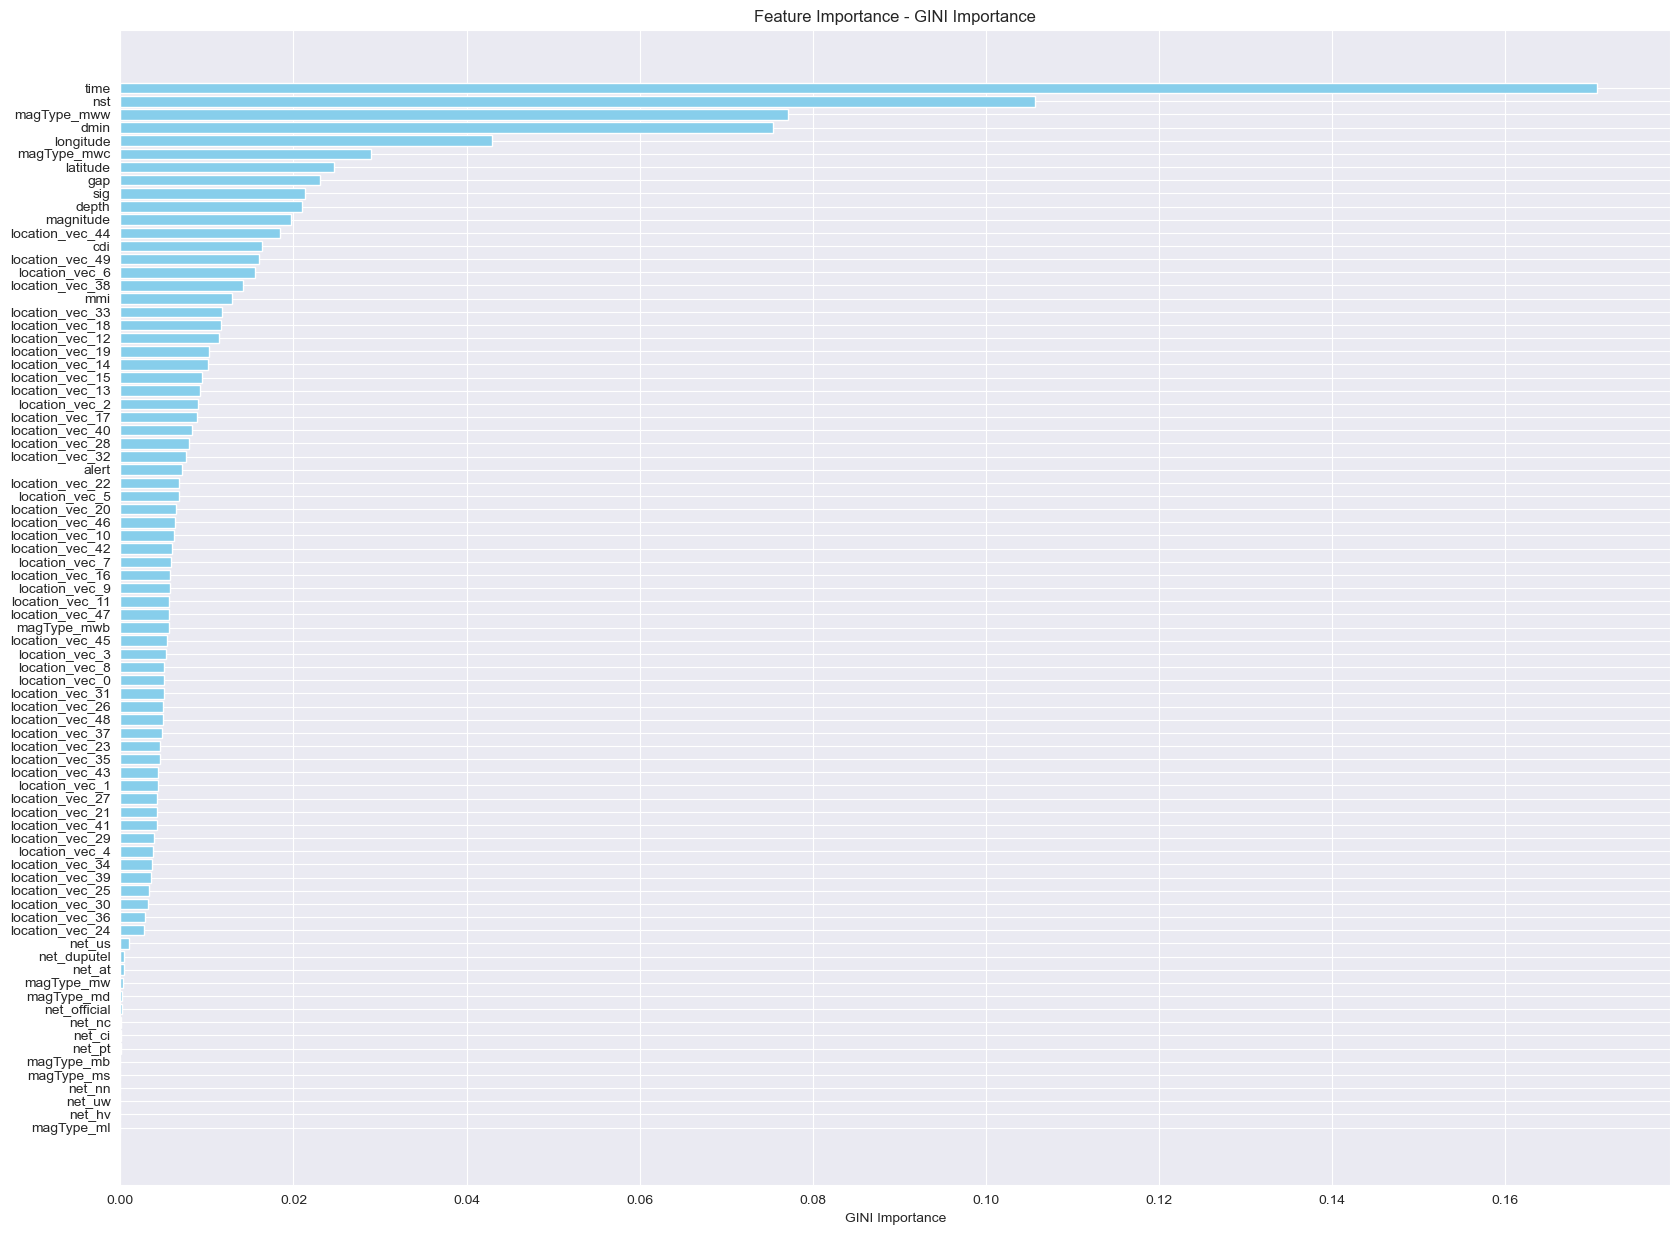

In [119]:
plt.figure(figsize=(20, 15))
plt.barh(feature_imp_df['Features'], feature_imp_df['GINI Importance'], color='skyblue')
plt.xlabel('GINI Importance')
plt.title('Feature Importance - GINI Importance')
plt.gca().invert_yaxis()
plt.show()

loosely based on: (GeeksForGeeks, 2025)

In [120]:
#model is learning temportal patterns instead of earthquake patterns, so lets drop time.
X_train_importance = X_train.drop(columns=['time'])
X_train_importance = calculate_gini_importance(X_train_importance, y_train)

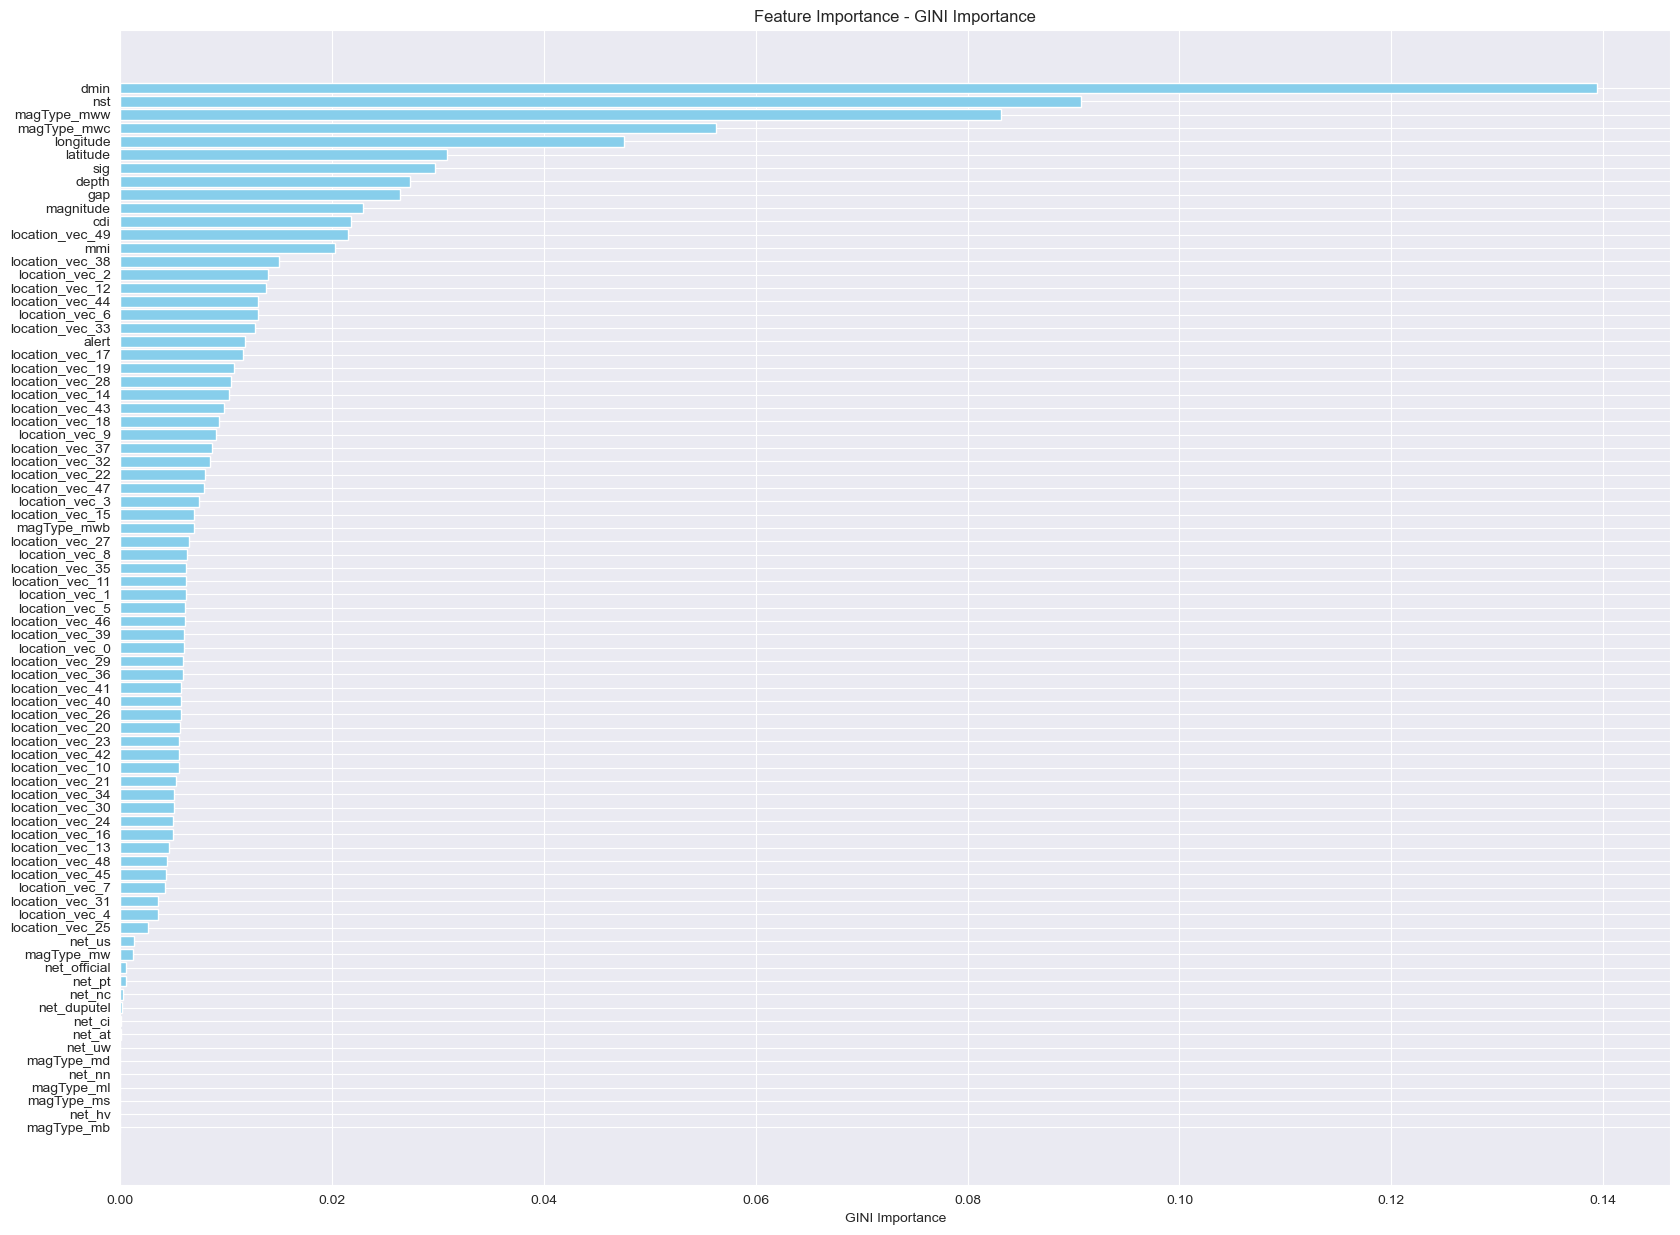

In [121]:
plt.figure(figsize=(20, 15))
plt.barh(X_train_importance['Features'], X_train_importance['GINI Importance'], color='skyblue')
plt.xlabel('GINI Importance')
plt.title('Feature Importance - GINI Importance')
plt.gca().invert_yaxis()
plt.show()

In [122]:
X_train = X_train.drop(columns=['time'])
X_test = X_test.drop(columns=['time'])

In [124]:
#get all net columns
net_columns = []
for col in X_train.columns:
    if col.startswith('net_'):
        net_columns.append(col)
#get there importance
net_importance = X_train_importance[X_train_importance['Features'].isin(net_columns)]
print(net_importance)

        Features  GINI Importance
19        net_us         0.001268
17  net_official         0.000513
18        net_pt         0.000495
15        net_nc         0.000273
13   net_duputel         0.000111
12        net_ci         0.000063
11        net_at         0.000052
20        net_uw         0.000000
16        net_nn         0.000000
14        net_hv         0.000000


In [125]:
X_train = X_train.drop(columns=net_columns)
X_test = X_test.drop(columns=net_columns)

Total Gini Importance of location vector features: 0.38107776510866753
Gini Importance of nst feature: 0.09071508696653997


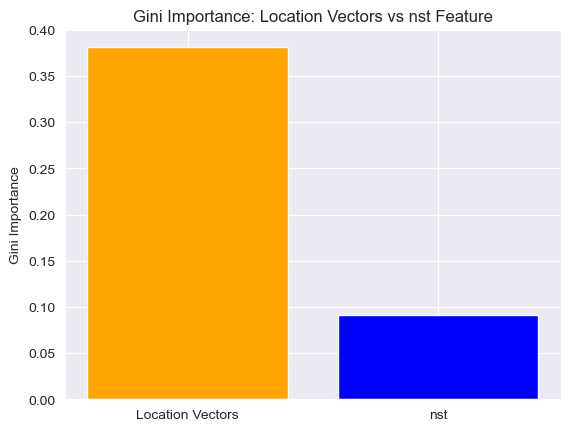

In [132]:
location_vector_columns = [col for col in X_train.columns if col.startswith('location_vec_')]
location_vector_importance = X_train_importance[X_train_importance['Features'].isin(location_vector_columns)]
total_location_vector_importance = location_vector_importance['GINI Importance'].sum()
print(f'Total Gini Importance of location vector features: {total_location_vector_importance}')
#compare with nst importance
nst_importance = X_train_importance[X_train_importance['Features'] == 'nst']['GINI Importance'].values[0]
print(f'Gini Importance of nst feature: {nst_importance}')
#plot comparison
plt.bar(['Location Vectors', 'nst'], [total_location_vector_importance, nst_importance], color=['orange', 'blue'])
plt.title('Gini Importance: Location Vectors vs nst Feature')
plt.ylabel('Gini Importance')
plt.show()

GPT REFERENCE

In [133]:
#drop magtype columns with low importance
magtype_columns = []
for col in X_train.columns:
    if col.startswith('magType_'):
        magtype_columns.append(col)

In [134]:
magtype_drop_columns = ['magType_mb', 'magType_ms', 'magType_ml', 'magType_md', 'magType_mw', 'magType_mwb']
X_train = X_train.drop(columns=magtype_drop_columns)
X_test = X_test.drop(columns=magtype_drop_columns)

In [135]:
#feature engineer a general significance feature
X_train['general_significance'] = X_train[['sig', 'magnitude', 'cdi', 'mmi']].mean(axis=1)
X_test['general_significance'] = X_test[['sig', 'magnitude', 'cdi', 'mmi']].mean(axis=1)

In [136]:
#General position feature
X_train['general_position'] = X_train[['latitude', 'longitude', 'depth']].mean(axis=1)
X_test['general_position'] = X_test[['latitude', 'longitude', 'depth']].mean(axis=1)

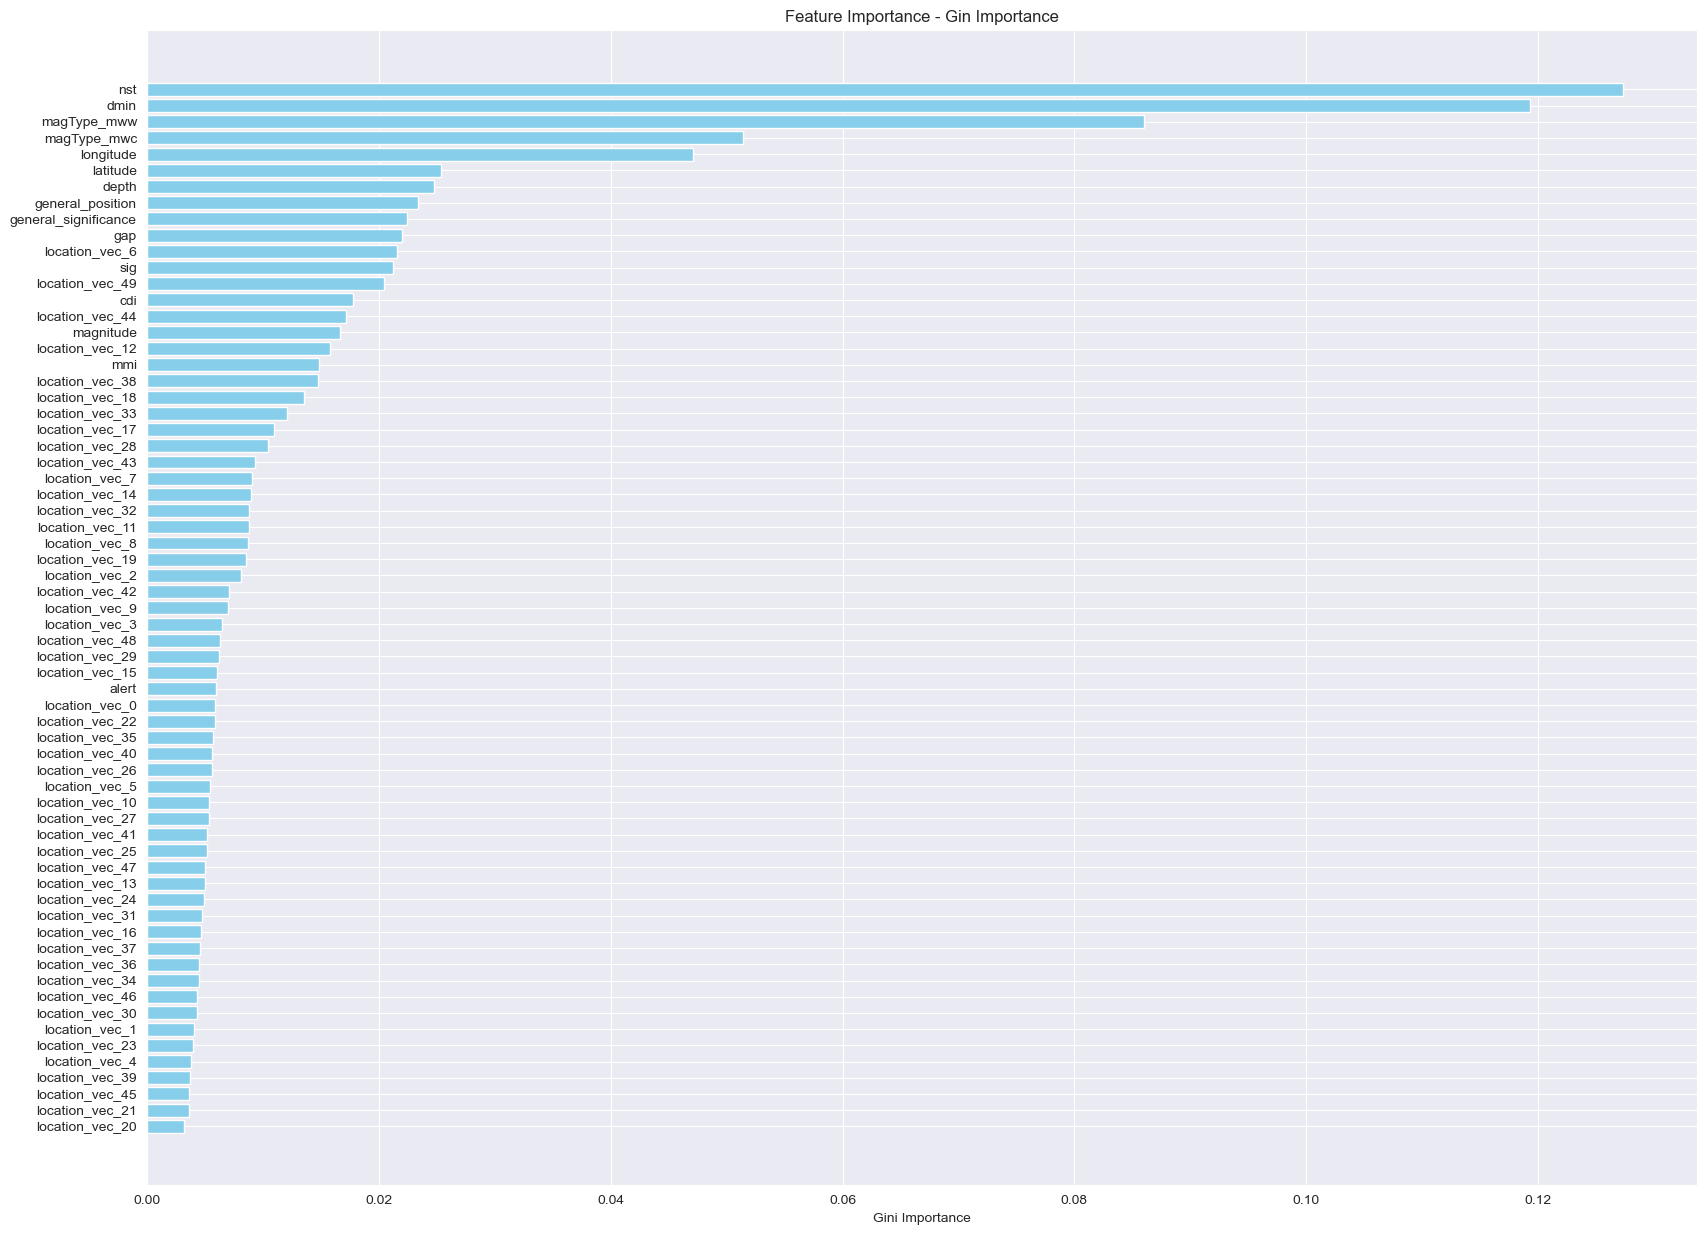

In [137]:
feature_imp_df = calculate_gini_importance(X_train, y_train)
#plot updated feature importance
plt.figure(figsize=(20, 15))
plt.barh(feature_imp_df['Features'], feature_imp_df['GINI Importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gin Importance')
plt.gca().invert_yaxis()
plt.show()

In [139]:
from sklearn.inspection import permutation_importance
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=0, n_jobs=-1)
perm_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Permutation Importance': result.importances_mean}).sort_values('Permutation Importance', ascending=False)
print(perm_imp_df)

/opt/anaconda3/envs/TsunamiRiskModelConda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/TsunamiRiskModelConda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/envs/TsunamiRiskModelConda/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11

                 Feature  Permutation Importance
6                   dmin                0.080769
5                    nst                0.056410
11           magType_mwc                0.015385
12           magType_mww                0.007692
41       location_vec_28                0.003846
..                   ...                     ...
46       location_vec_33               -0.009615
20        location_vec_7               -0.009615
63  general_significance               -0.009615
9               latitude               -0.010897
8                  depth               -0.019231

[65 rows x 2 columns]


### An imbalnced dataset

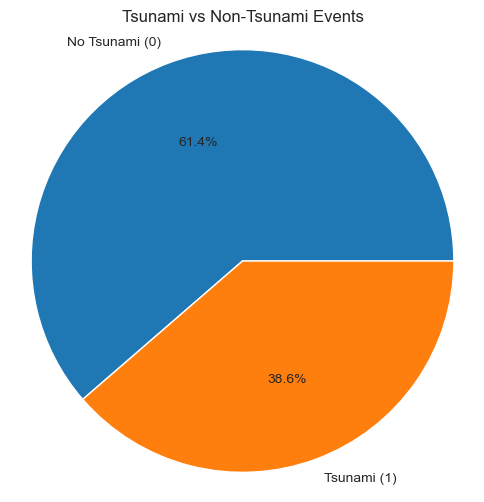

In [64]:
plt.figure(figsize=(6,6))
plt.pie(y.value_counts(), labels=['No Tsunami (0)', 'Tsunami (1)'], autopct='%1.1f%%')
plt.title('Tsunami vs Non-Tsunami Events')
plt.axis('equal')
plt.show()

This pie chart shows that our dataset is imbalanced, with a significantly higher proportion of non-tsunami events (0) compared to tsunami events (1).
#### Class weights

In order to address this class imbalance during model training, we can use class weights. Class weights assign a higher weight to the minority class (tsunami events) and a lower weight to the majority class (non-tsunami events). This helps the model pay more attention to the minority class during training, improving its ability to correctly classify tsunami events.

### Data limitation and quality issues

Throughout the EDA and data preprocessing steps, we have identified and addressed several data quality issues that could impact our modeling efforts:

- The dataset is generally small with only 779 samples after cleaning, which limits the complexity of models we can use without overfitting. We have taken care to avoid overfitting.

 - It seems our dataset has a left skewed distribution of across serveral features, which may impact model performance. However, given our dataset size constraints, we have applied log transformation to features with extreme outliers to help reduce skewness where possible.

- We identified and handled missing values in several features using appropriate imputation strategies based on the nature of the data and relationships between features. However, this is not a perfect solution, and some uncertainty remains due to the imputation process, but given the limitation created by the missing data and our dataset size, this is the best approach available.

- USGS is our sole data source, which may introduce collection bias or limitations based on their data collection methods and coverage. Relying on a single source can limit the diversity of data and potentially overlook important factors influencing tsunami occurrences. This is confirmed by (United States Geological Survey, 2022) which acknowledges that not all earthquakes are recorded and minor earthquakes within the United States are more likely to be captured than those in other regions.



In [65]:
#TODO: Hyperparameter tuning (Grid and Randomized Search)


In [66]:
#TODO: explore auto parameter tuning

### References:

Chauhan, C. (2025) Earthquake dataset. Kaggle. Available from: https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_data.csv [Accessed 24 October 2025].

United States Geological Survey (USGS) (no date) Earthquake Hazards Program Glossary. U.S. Geological Survey. Available from: https://www.usgs.gov/glossary/earthquake-hazards-program [Accessed 26 October 2025].
CDI Wald, D.J., Quitoriano, V., Worden, C.B., Hopper, M. and Dewey, J.W. (2011) ‘USGS “Did You Feel It?”: Internet-based macroseismic intensity maps’, Annals of Geophysics, 54(6), pp. 688–707. Available from: https://www.researchgate.net/publication/268368064_USGS_Did_You_Feel_It_Internet-based_macroseismic_intensity_maps [Accessed 26 October 2025].

United States Geological Survey (USGS) (1989) Modified Mercalli Intensity Scale. U.S. Geological Survey. Available from: https://www.usgs.gov/programs/earthquake-hazards/modified-mercalli-intensity-scale [Accessed 26 October 2025].
United States Geological Survey (USGS) (2010) PAGER Scientific Background. U.S. Geological Survey. Available from: https://earthquake.usgs.gov/data/pager/background.php [Accessed 26 October 2025].

United States Geological Survey (no date) PAGER Scientific Background. U.S. Geological Survey. Available from: https://earthquake.usgs.gov/data/pager/background.php [Accessed 3 November 2025].

itdxer (2017) ‘What does average of word2vec vector mean?’, Cross Validated – Statistics Stack Exchange, 14 December. Available from: https://stats.stackexchange.com/questions/318882/what-does-average-of-word2vec-vector-mean[Accessed 3 November 2025].

United States Geological Survey (2022) Why is the earthquake that was reported/recorded by network X, or that I felt, not on the Latest Earthquakes map/list? Available from: https://www.usgs.gov/faqs/why-earthquake-was-reportedrecorded-network-x-or-i-felt-not-latest-earthquakes-maplist [Accessed 3 November 2025]

A l w a y s S u n n y, 2019. pandas convert from datetime to integer timestamp [online]. Stack Overflow. Available at: https://stackoverflow.com/questions/54312802/pandas-convert-from-datetime-to-integer-timestamp [Accessed 4 Nov. 2025].

GeeksforGeeks, 2025. Feature Importance with Random Forests. [online] Available at: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/?utm_source=chatgpt.com [Accessed 4 November 2025].